# Project Citibike network

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import binom

import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
import networkx.algorithms.community as nx_comm
from collections import defaultdict
from scipy.stats import percentileofscore
import powerlaw



# Load the data

In [2]:
# use dtype=str to avoid the "Mixed Type" warning
df = pd.read_csv('JC-202402-citibike-tripdata.csv', dtype={'start_station_name': str, 'end_station_name': str})

df.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,A841EF9C3617E47B,electric_bike,2024-02-12 16:17:19,2024-02-12 16:23:24,Adams St & 2 St,HB407,Stevens - River Ter & 6 St,HB602,40.739701,-74.036831,40.743133,-74.026989,casual
1,514881A61CAD0A93,electric_bike,2024-02-04 15:04:16,2024-02-04 15:40:14,Adams St & 2 St,HB407,Stevens - River Ter & 6 St,HB602,40.739741,-74.036824,40.743133,-74.026989,casual
2,511F37086CCC4510,electric_bike,2024-02-16 16:23:16,2024-02-16 16:27:16,Clinton St & Newark St,HB409,Stevens - River Ter & 6 St,HB602,40.737508,-74.035715,40.743133,-74.026989,casual
3,27A2AA8BDD0D1F6E,classic_bike,2024-02-25 17:05:01,2024-02-25 17:10:53,Adams St & 2 St,HB407,Stevens - River Ter & 6 St,HB602,40.739814,-74.036904,40.743133,-74.026989,member
4,2808ABEC0903C18E,electric_bike,2024-02-29 15:21:15,2024-02-29 15:26:03,Adams St & 2 St,HB407,Stevens - River Ter & 6 St,HB602,40.739712,-74.036858,40.743133,-74.026989,member


# Clean the data

In [3]:
# remove rows with missing station ids
df = df.dropna(subset=['start_station_name', 'end_station_name'])
# remove self-loops (stations with equal start and end station id's)
df = df[df["start_station_name"] != df["end_station_name"]]


# Create a Weighted Graph

In [5]:
# A Link is a trip. Weight is the number of trips between two stations
links_df = df.groupby(['start_station_name', 'end_station_name']).size().reset_index(name='weight')
#filter no connection nodes
G_o = nx.from_pandas_edgelist(links_df, 
                            source='start_station_name', 
                            target='end_station_name', 
                            edge_attr='weight')
largest_cc = max(nx.connected_components(G_o), key=len)
G = G_o.subgraph(largest_cc)

# add lat/long attributes to nodes for geo-layout
nx.set_node_attributes(
    G,
    pd.concat([
        df[['start_station_name','start_lat','start_lng']].rename(columns={'start_station_name':'name','start_lat':'lat','start_lng':'lng'}),
        df[['end_station_name','end_lat','end_lng']].rename(columns={'end_station_name':'name','end_lat':'lat','end_lng':'lng'})
    ]).groupby('name')[['lat','lng']].mean().to_dict('index')
)

# Basic Statistics

In [6]:
num_nodes = len(G)          # number of nodes
num_edges = len(G.edges)    # number  of edges
num_connected_components = nx.number_connected_components(G) # number of components
average_degree = 2*num_edges/num_nodes # average degree
average_clustering = nx.average_clustering(G) # average clustering
average_shortest_path = nx.average_shortest_path_length(G) # average SPL

print("Number of nodes", num_nodes)
print("Number of edges", num_edges)
print("Number connected components", num_connected_components)
print("Average degree: ", average_degree)
print("Average clustering coefficient: ", average_clustering)
print("Average shortest path length: ", average_shortest_path)

Number of nodes 134
Number of edges 2528
Number connected components 1
Average degree:  37.73134328358209
Average clustering coefficient:  0.6023377581450108
Average shortest path length:  1.9667826282123217


## Degree Distribution (including fit)

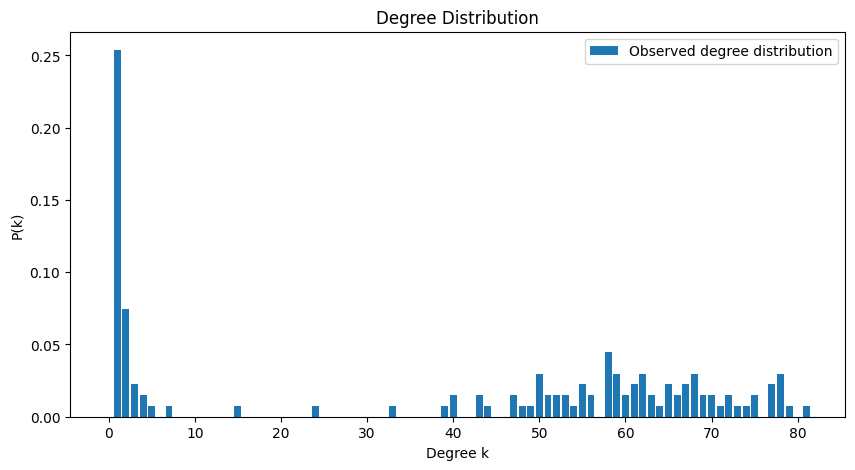

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 43/43 [00:00<00:00, 559.25it/s]


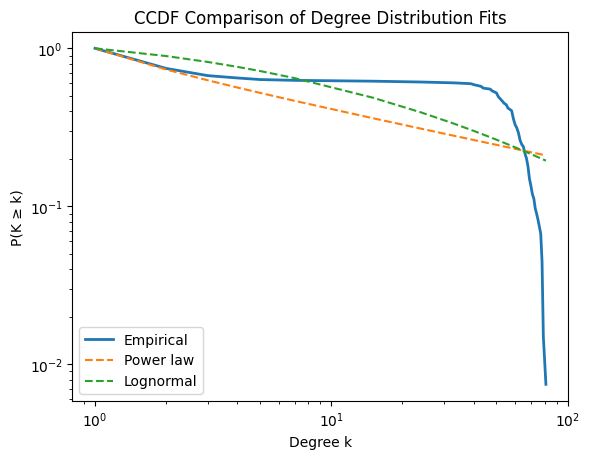

In [77]:
degree_dict = dict(nx.degree(G))
df = pd.DataFrame({"Degree": pd.Series(degree_dict),})

# Empirical degree distribution
K = int(df["Degree"].max())
y0, x0 = np.histogram(df["Degree"].values, bins=range(K + 2), density=True)

# Degree distribution plot
plt.figure(figsize=(10, 5))
plt.bar(x0[:-1], y0, label="Observed degree distribution")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("Degree Distribution")
plt.legend()
plt.show()

# Get degree sequence
degrees = [d for n, d in G.degree()]

# Fit power law
fit = powerlaw.Fit(degrees, discrete=True)

# plot CCDF with different distribution fits
fig = fit.plot_ccdf(label='Empirical', linewidth=2)
fit.power_law.plot_ccdf(ax=fig, linestyle='--', label='Power law')
fit.lognormal.plot_ccdf(ax=fig, linestyle='--', label='Lognormal')
plt.xlabel("Degree k")
plt.ylabel("P(K ≥ k)")
plt.title("CCDF Comparison of Degree Distribution Fits")
plt.legend()
plt.show()






# Density Based on Weighted Edge Thresholds

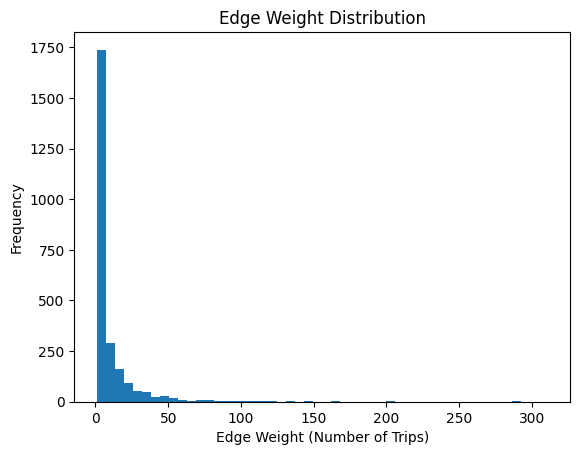

Threshold = 0, percentile = 0.0 N = 141, E = 2532, Density = 0.25653495440729485
Threshold = 5, percentile = 59.909018987341774 N = 134, E = 1230, Density = 0.1380316462798788
Threshold = 10, percentile = 74.36708860759494 N = 134, E = 790, Density = 0.08865447200089777
Threshold = 15, percentile = 82.06091772151899 N = 134, E = 571, Density = 0.0640781057120413
Threshold = 20, percentile = 86.94620253164558 N = 134, E = 419, Density = 0.04702053641566603
Threshold = 25, percentile = 89.89319620253166 N = 134, E = 325, Density = 0.03647177645606554
Threshold = 30, percentile = 91.77215189873418 N = 134, E = 248, Density = 0.027830770957243855


In [13]:

weights = [weight['weight'] for source, target, weight in G.edges(data=True)]
weight_filtered_graphs = []
weight_thresholds = [0, 5, 10, 15, 20, 25, 30]
percentiles = [percentileofscore(weights, threshold) for threshold in weight_thresholds]

# plot the weight distribution
plt.figure()
plt.hist(weights, bins=50)
plt.xlabel("Edge Weight (Number of Trips)")
plt.ylabel("Frequency")
plt.title("Edge Weight Distribution")
plt.show()

# create graphs for each level of weight threshold
for weight_threshold in weight_thresholds:
    filtered_links = links_df[links_df['weight'] >= weight_threshold].copy()

    filtered_graph = nx.from_pandas_edgelist(filtered_links, source='start_station_name', target='end_station_name', edge_attr='weight')

    filtered_graph.add_nodes_from(G.nodes(data=True))

    weight_filtered_graphs.append(filtered_graph)

# report the density of each filtered graph
for index, graph in enumerate(weight_filtered_graphs):
    print(f"Threshold = {weight_thresholds[index]}, percentile = {percentiles[index]} N = {graph.number_of_nodes()}, E = {graph.number_of_edges()}, Density = {nx.density(graph)}")
    

# Navigability Statistics & Small World

In [14]:
# compute average clustering and path length for the real graph
C = nx.average_clustering(G)
print("Average clustering coefficient: ", C)
L = nx.average_shortest_path_length(G)
print("Average shortest path length: ", L)
diameter = nx.diameter(G)
print("Diameter: ", diameter)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Generate random graphs with same number of nodes and edges
num_random = 100
C_r_list = []
L_r_list = []

# calculate mean avg clustering and path length for small-world comparison
for _ in range(num_random):
    G_r = nx.gnm_random_graph(num_nodes, num_edges)
    
    # largest connected component for avg path calculation
    if not nx.is_connected(G_r):
        largest_cc = max(nx.connected_components(G_r), key=len)
        G_r = G_r.subgraph(largest_cc).copy()
    
    C_r_list.append(nx.average_clustering(G_r))
    L_r_list.append(nx.average_shortest_path_length(G_r))

C_r = np.mean(C_r_list)
L_r = np.mean(L_r_list)

print(f"Random clustering C_r = {C_r}")
print(f"Random path length L_r = {L_r}")


Average clustering coefficient:  0.6023377581450108
Average shortest path length:  1.9667826282123217
Diameter:  4
Random clustering C_r = 0.28374245107828616
Random path length L_r = 1.7163180338906974


# Network Metrics for Visualization

In [16]:
# calculate Betweenness Centrality for node sizing
betweenness = nx.betweenness_centrality(G, weight='weight')
nx.set_node_attributes(G, betweenness, 'betweenness')

# calculate Degree 
degree = dict(G.degree(weight='weight'))
nx.set_node_attributes(G, degree, 'degree_weight')

degree_cent = nx.degree_centrality(G)
# use weight='weight' for betweenness to account for trip volume
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

nx.set_node_attributes(G, degree_cent, "degree_centrality")
nx.set_node_attributes(G, betweenness_cent, "betweenness_centrality")

# Community Detection and Modularity Score

In [75]:
partition = community_louvain.best_partition(G, weight='weight')
nx.set_node_attributes(G, partition, "modularity_class")
# convert partition dict to a list of sets for NetworkX
communities = [set() for _ in range(max(partition.values()) + 1)]
for node, community_id in partition.items():
    communities[community_id].add(node)

modularity_score = nx_comm.modularity(G, communities, weight='weight')

print(f"Modularity Score: {modularity_score:.4f}")

# compare modularity to random network 

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Generate random graphs with same number of nodes and edges
num_random = 100
M_r_list = []
degree_centrality_list = []

# calculate mean modularity score of a similar sized random ensemble for comparison 
for _ in range(num_random):
    G_r = nx.gnm_random_graph(num_nodes, num_edges)
    partition_r = community_louvain.best_partition(G_r)
    M_r_list.append(community_louvain.modularity(partition_r, G_r))

M_r = np.mean(M_r_list)

print(f"Random Modularity Score: {M_r:.4f}")

Modularity Score: 0.4280
Random Modularity Score: 0.1090


# Centrality Measures


Top 5 Hubs (Degree):
  Station Newport PATH: 0.6090
  Station Washington St: 0.5940
  Station Hamilton Park: 0.5865
  Station Hoboken Terminal - River St & Hudson Pl: 0.5865
  Station Newark Ave: 0.5865


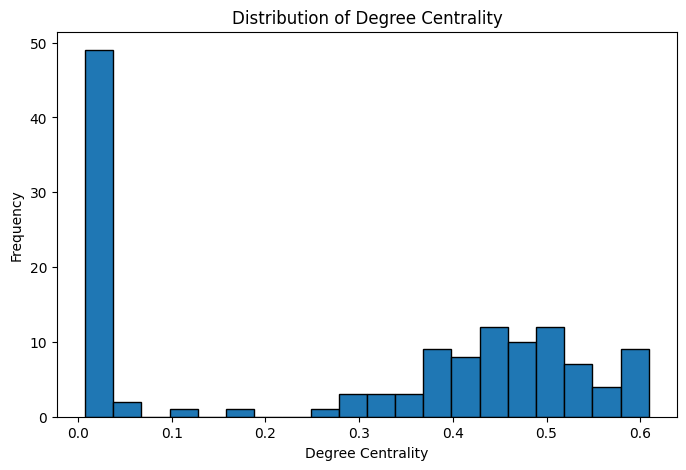


Top 5 Betweenness Centralities:
  Station Grand St: 0.0803
  Station Paulus Hook: 0.0736
  Station 12 St & Sinatra Dr N: 0.0517
  Station Southwest Park - Jackson St & Observer Hwy: 0.0507
  Station JC Medical Center: 0.0449


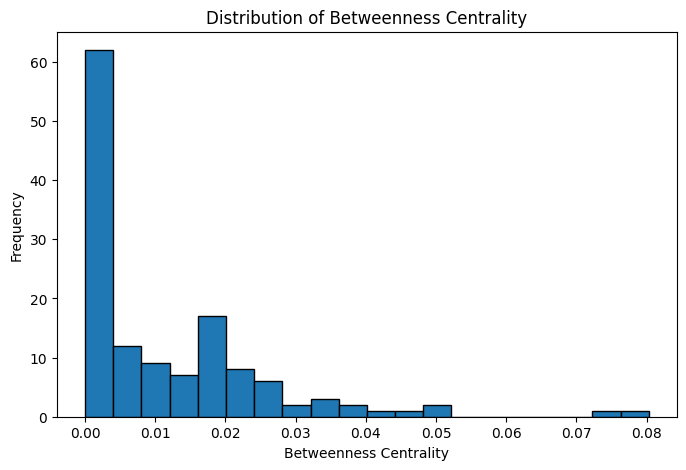

Component 1 size: 131
Component 2 size: 1
Component 3 size: 1

Top 5 Betweenness Centralities:
  Station Newport PATH: 0.7151
  Station Newark Ave: 0.7074
  Station Washington St: 0.7074
  Station Hamilton Park: 0.7037
  Station Hoboken Terminal - River St & Hudson Pl: 0.7037
  Station Exchange Pl: 0.7037
  Station Harborside: 0.6963
  Station Grand St: 0.6963
  Station City Hall - Washington St & 1 St: 0.6927
  Station Columbus Drive: 0.6891
  Station Newport Pkwy: 0.6891
  Station Grove St PATH: 0.6821
  Station Warren St: 0.6821
  Station Brunswick St: 0.6717
  Station Brunswick & 6th: 0.6717
  Station Hoboken Ave at Monmouth St: 0.6683
  Station Pershing Field: 0.6683
  Station River St & 1 St: 0.6650
  Station Hoboken Terminal - Hudson St & Hudson Pl: 0.6584
  Station Southwest Park - Jackson St & Observer Hwy: 0.6552
  Station City Hall: 0.6552
  Station Clinton St & Newark St: 0.6520
  Station Jersey & 3rd: 0.6520
  Station 4 St & River St: 0.6488
  Station Montgomery St: 0.6488

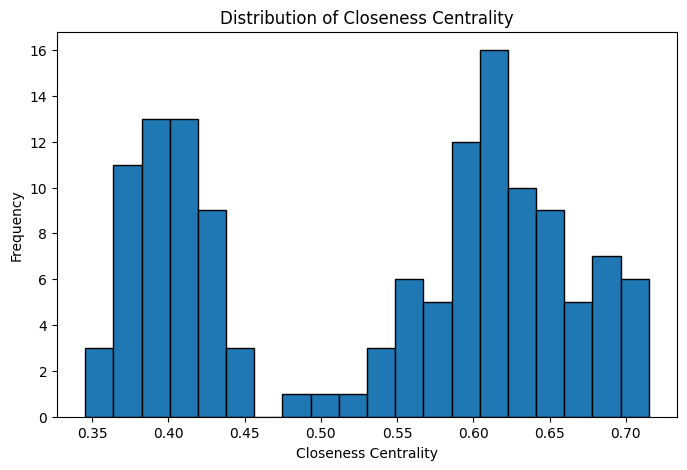

In [ ]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True, weight='weight')
closeness_centrality = nx.closeness_centrality(G)

degree_values = list(degree_centrality.values())
betweenness_values = list(betweenness_centrality.values())
closeness_values = list(closeness_centrality.values())

# Top 5 Hubs (Degree Centrality)
# these are the 'Social Butterflies' of the network with the most connections
top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Hubs (Degree):")
for station, value in top_hubs:
    print(f"  Station {station}: {value:.4f}")

# Degree centrality Distribution
plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=20, edgecolor='black')
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.title("Distribution of Degree Centrality")
plt.show()


# these are the 'Gatekeepers' that hold different neighborhoods together
top_bridges = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Betweenness Centralities:")
for station, value in top_bridges:
    print(f"  Station {station}: {value:.4f}")

# Betweeness centrality Distribution
plt.figure(figsize=(8, 5))
plt.hist(betweenness_values, bins=20, edgecolor='black')
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frequency")
plt.title("Distribution of Betweenness Centrality")
plt.show()

# Result of removing Grand St (highest betweenness centrality station)
G_removed = G.copy()
G_removed.remove_node("Grand St")
components = list(nx.connected_components(G_removed))
for i, comp in enumerate(components):
    print(f"Component {i+1} size: {len(comp)}")

# Top-5 Closeness centrality stations
top_neighbors = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 Betweenness Centralities:")
for station, value in top_neighbors:
    print(f"  Station {station}: {value:.4f}")

# Closeness centrality distribution
plt.figure(figsize=(8, 5))
plt.hist(closeness_values, bins=20, edgecolor='black')
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.title("Distribution of Closeness Centrality")
plt.show()


# Export for Gephi

In [20]:
nx.write_gexf(G, "citibike_network_202402.gexf")

# ERDOS RENYI RANDOM GRAPH - NULL MODEL1

In [41]:
N = len(G) #number of nodes
L = len(G.edges) #numb of edges
k = 2*L/N # average degree

L_ER = len(G.nodes())
Lmax_ER = L_ER *( L_ER -1 )/ 2
actualL_ER = len(G.edges())
p = actualL_ER/ Lmax_ER

ER = nx.erdos_renyi_graph(L_ER, p, directed=False)

In [42]:
degree_dict_ER = dict(nx.degree(ER))
clustering_dict_ER = nx.clustering(ER)
df_ER = pd.DataFrame([degree_dict_ER, clustering_dict_ER]).T
df_ER.columns = ["Degree", "Clustering"]
df_ER.head()

,Degree,Clustering
0,34.0,0.281640
1,43.0,0.283499
2,36.0,0.280952
3,34.0,0.304813
4,38.0,0.280228


In [43]:
K_ER= df_ER.Degree.max()
K_ER

np.float64(50.0)

Text(0.5, 1.0, 'ER Degree Distribution')

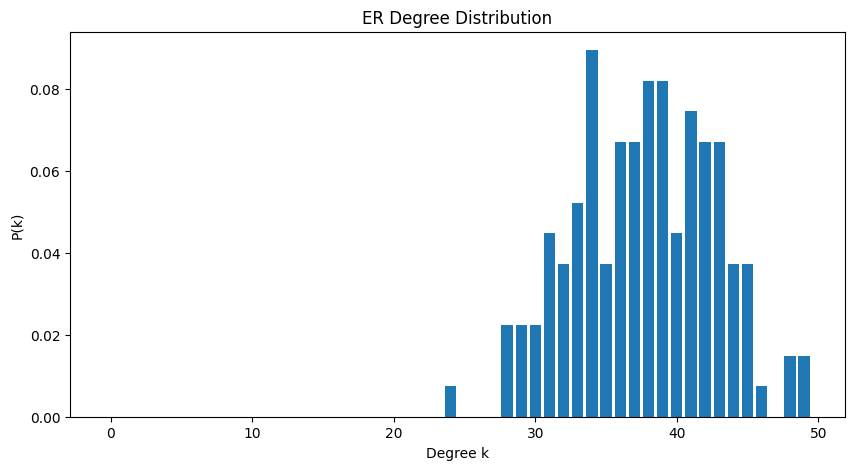

In [44]:
y0_ER, x0_ER = np.histogram(df_ER.Degree.values, bins= range(int(K_ER)+1), density=True)
plt.figure(figsize=(10, 5))
plt.bar(x0_ER[:-1],y0_ER)
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('ER Degree Distribution')

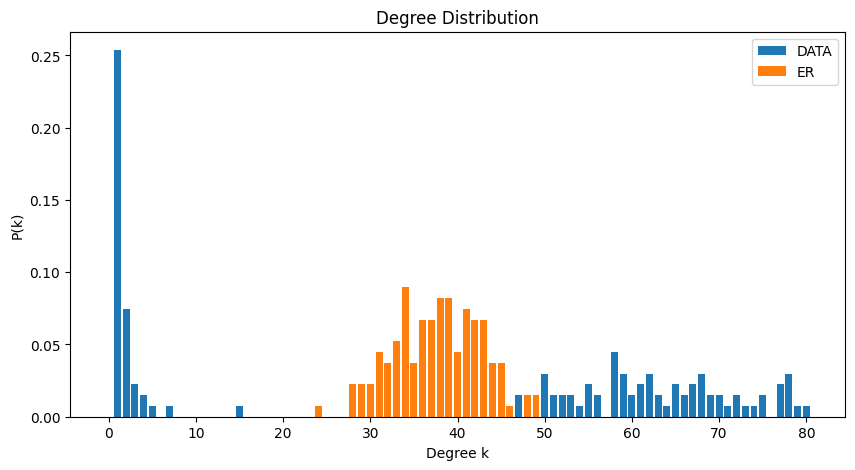

In [45]:
plt.figure(figsize=(10, 5))
y0,x0 = np.histogram(df.Degree.values, bins = range(int(K)+1), density= True)

plt.bar(x0[:-1],y0, label= "DATA")

y0_ER, x0_ER = np.histogram(df_ER.Degree.values, bins= range(int(K_ER)+1), density=True)
plt.bar(x0_ER[:-1],y0_ER, label= "ER")
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution')

plt.legend()

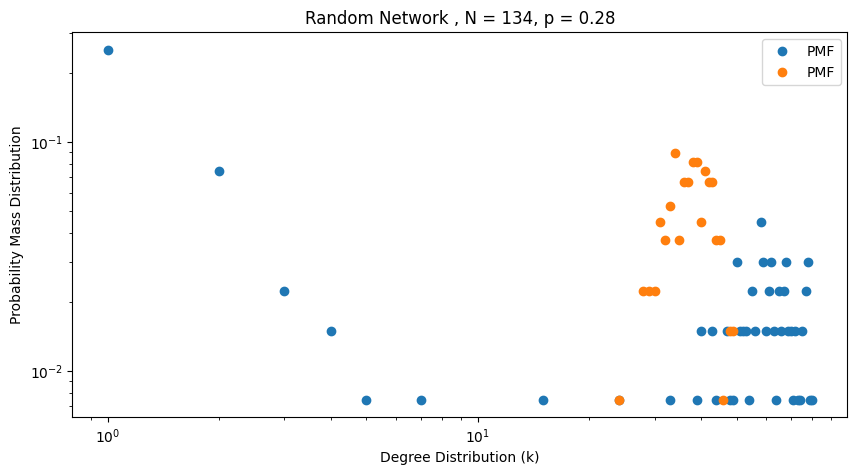

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(x0[:-1], y0, 'o', label = 'PMF')
plt.plot(x0_ER[:-1], y0_ER, 'o', label = 'PMF')

#Applying log to both axis
plt.xscale('log')
plt.yscale('log')

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

In [47]:
C_ER = np.mean(list(nx.clustering(ER).values()))
d_ER = nx.average_shortest_path_length(ER,weight=None)

print("Average Clustering Coefficient: ", C_ER)
print("Average Shortest Path: ", d_ER)

Average Clustering Coefficient:  0.2835012781141119
Average Shortest Path:  1.7167545729996634


# Degree Preservation Configuration Model GRAPH - NULL MODEL2

In [48]:
deg_seq = [G.degree(n) for n in G.nodes()]
Gdp = nx.configuration_model(deg_seq)
Gdp = nx.Graph(Gdp)  
Gdp.remove_edges_from(nx.selfloop_edges(Gdp)) # remove multiple edges

In [49]:
degree_dict_DP = dict(nx.degree(Gdp)) #Creating a dictionary of the degrees of the network
clustering_dict_DP = nx.clustering(Gdp) #Creating a dictionary with the clustering coefficients
df_DP = pd.DataFrame([degree_dict_DP, clustering_dict_DP]).T #Writting this above as a dataframe
df_DP.columns = ['Degree', 'Clustering']
df_DP.head()

,Degree,Clustering
0,40.0,0.434615
1,4.0,0.666667
2,43.0,0.532669
3,40.0,0.501282
4,46.0,0.436715


In [50]:
K_DP = df_DP.Degree.max()
K

81

Text(0.5, 1.0, 'DP Degree Distribution')

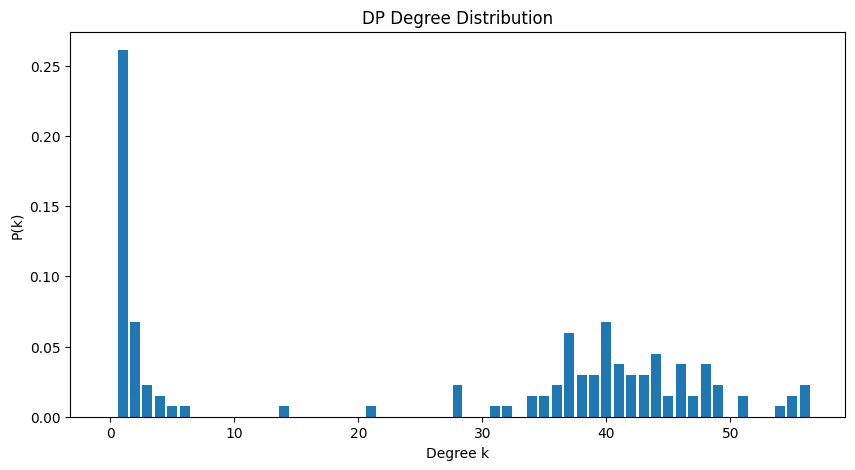

In [51]:
y0_DP, x0_DP = np.histogram(df_DP.Degree.values, bins= range(int(K_DP)+1), density=True)
plt.figure(figsize=(10, 5))
plt.bar(x0_DP[:-1],y0_DP)
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('DP Degree Distribution')

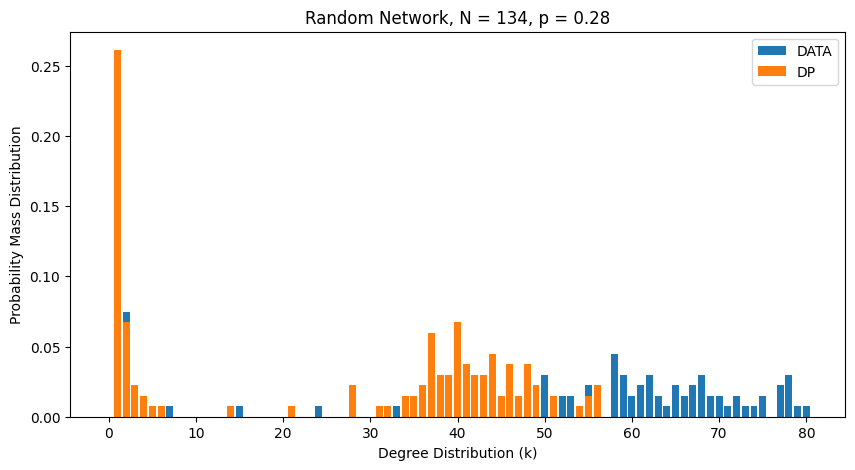

In [52]:
plt.figure(figsize=(10, 5))
y0,x0 = np.histogram(df.Degree.values, bins = range(int(K)+1), density= True)
plt.bar(x0[:-1],y0, label= "DATA")

y0_DP, x0_DP = np.histogram(df_DP.Degree.values, bins= range(int(K_DP)+1), density=True)
plt.bar(x0_DP[:-1],y0_DP, label= "DP")
plt.title('Random Network, N = %i, p = %1.2f' %(N,p))
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')

plt.legend()

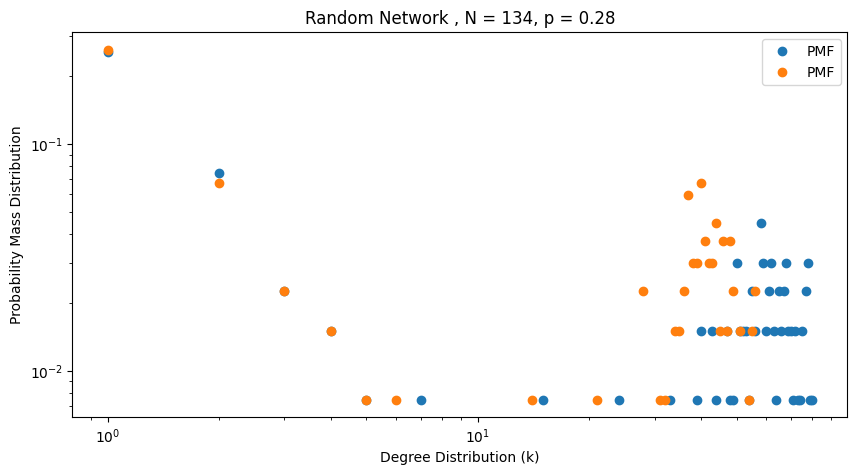

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(x0[:-1], y0, 'o', label = 'PMF')
plt.plot(x0_DP[:-1], y0_DP, 'o', label = 'PMF')

#Applying loh to both axis
plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

In [54]:
# function of computing average neighbour degree
def compute_knn(G):
    knn_dict = defaultdict(list)
    for n in G.nodes():
        k = G.degree(n)
        neigh_degs = [G.degree(neigh) for neigh in G.neighbors(n)]
        if neigh_degs:
            knn_dict[k].append(np.mean(neigh_degs))
    knn = {k: np.mean(knn_dict[k]) for k in knn_dict}
    return knn
knn_data = compute_knn(G)

# Ensemble for ER

In [55]:
num_ens = 1000 # use 1000 for more accuracy
clustering_ER = []
short_path_ER = []
degree_histograms_ER = []      # store the full histogram for each graph
max_degree_ER = 0      # track max degree across ensemble to set common bins
knn_lists_ER = []

for i in range(num_ens): 
    
    ER = nx.erdos_renyi_graph(L_ER, p, directed=False)
    C_ER = np.mean(list(nx.clustering(ER).values()))
    # average shortest path (only if connected)
    if nx.is_connected(ER)==True:
        d_ER = nx.average_shortest_path_length(ER,weight=None)
        short_path_ER.append(d_ER)
    clustering_ER.append(C_ER)
    # Degree histogram (probability distribution)
    degrees = [d for n, d in nx.degree(ER)]
    # Choose bins: from 0 to max degree in this graph, align all histograms later
    hist, bins = np.histogram(degrees, bins=range(0, max(degrees)+2), density=True)
    # bins[:-1] are the left edges, store the histogram values aligned by degree
    degree_histograms_ER.append((bins[:-1], hist))  # store bins and probabilities
    
    # update max degree of ER for bin alignment
    if max(degrees) > max_degree_ER:
        max_degree_ER = max(degrees)
    knn_lists_ER.append(compute_knn(ER))

mean_C_ER = np.mean(clustering_ER)
std_C_ER = np.std(clustering_ER)
mean_d_ER = np.mean(short_path_ER)
std_d_ER = np.std(short_path_ER)
print(f"ER clustering: {mean_C_ER:.2f} ± {std_C_ER:.3f}")
print(f"ER avg path: {mean_d_ER:.2f} ± {std_d_ER:.3f}")

ER clustering: 0.28 ± 0.005
ER avg path: 1.72 ± 0.005


In [57]:
# average knn for ER
all_ks = set()
for dic in knn_lists_ER:
    all_ks.update(dic.keys())
knn_ER = {}
for k in all_ks:
    vals = [dic.get(k) for dic in knn_lists_ER if k in dic]
    if vals:
        knn_ER[k] = np.mean(vals)

# Align histograms and compute mean & std of P(k)

In [58]:
# determine common bins 
bins_common_ER = np.arange(0, max_degree_ER+2)
k_values_ER = bins_common_ER[:-1]   # the degree values

# initialize an array to collect probabilities for each graph
prob_matrix_ER = np.zeros((len(degree_histograms_ER), len(k_values_ER)))

for i, (bins_i, probs_i) in enumerate(degree_histograms_ER):
    # probs_i correspond to bins_i (left edges)
    # Map these probabilities into the common bin indices
    for j, k in enumerate(k_values_ER):
        # find if k is within the bins_i range
        if k < len(probs_i):   # because bins_i starts at 0 and goes to max degree of that graph
            prob_matrix_ER[i, j] = probs_i[k] if k < len(probs_i) else 0.0
        else:
            prob_matrix_ER[i, j] = 0.0

# Compute mean and std across the ensemble (axis=0)
mean_p_ER = np.mean(prob_matrix_ER, axis=0)
std_p_ER = np.std(prob_matrix_ER, axis=0)

# Plot the ensemble degree distribution with standard deviation

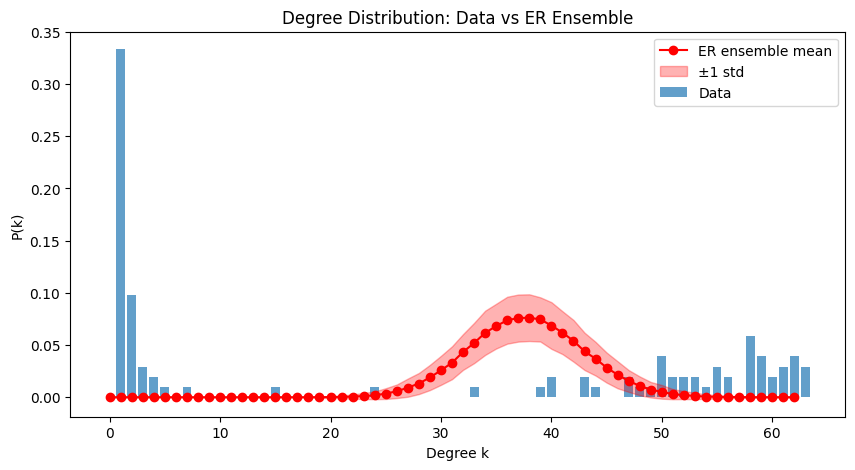

In [59]:
plt.figure(figsize=(10, 5))

# Data distribution 
y_data, x_data = np.histogram(df.Degree.values, bins=range(int(max_degree_ER+2)+1), density=True)
plt.bar(x_data[:-1], y_data, alpha=0.7, label="Data", width=0.8, align='center')

# ER ensemble mean and standaard deviation
plt.plot(k_values_ER, mean_p_ER, 'o-', color='red', label="ER ensemble mean")
plt.fill_between(k_values_ER, mean_p_ER - std_p_ER, mean_p_ER + std_p_ER, alpha=0.3, color='red', label="±1 std")

plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution: Data vs ER Ensemble')
plt.legend()
plt.show()

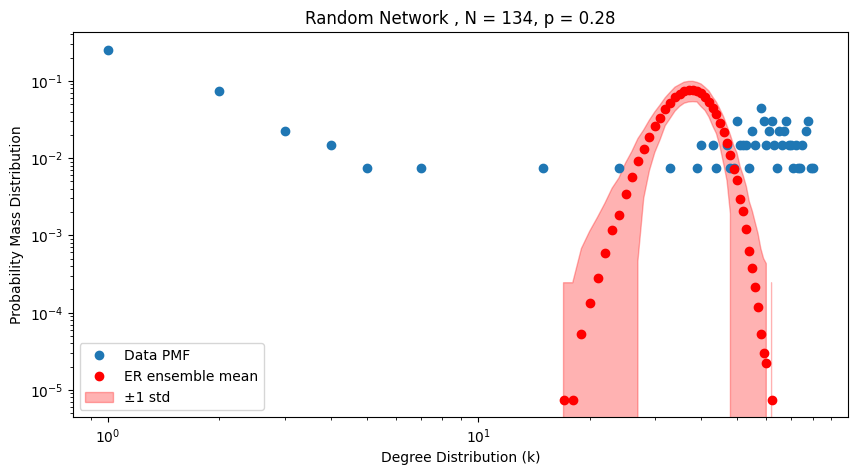

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(x0[:-1], y0, 'o', label = 'Data PMF')

plt.plot(k_values_ER, mean_p_ER, 'o', color='red', label="ER ensemble mean")
plt.fill_between(k_values_ER, mean_p_ER - std_p_ER, mean_p_ER + std_p_ER, alpha=0.3, color='red', label="±1 std")


#Applying log to both axis
plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))

plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

# Ensemble for DP

In [61]:
clustering_DP = []
short_path_DP = []
degree_histograms_DP = []         # store the full histogram for each graph
max_deg_DP = 0
deg_seq = [G.degree(n) for n in G.nodes()]
knn_lists_DP = []
for i in range(num_ens):
    Gdp = nx.configuration_model(deg_seq)
    Gdp = nx.Graph(Gdp) 
    Gdp.remove_edges_from(nx.selfloop_edges(Gdp))  # remove multiple edges
    clustering_DP.append(nx.average_clustering(Gdp))
    if nx.is_connected(Gdp):
        short_path_DP.append(nx.average_shortest_path_length(Gdp))

    # Degree histogram (probability distribution)
    degs = [d for n, d in Gdp.degree()]
    # Choose bins: from 0 to max degree in this graph, align all histograms later
    hist, bins = np.histogram(degs,
                              bins=np.arange(0, max(degs)+2),
                              density=True)
    # bins[:-1] are the left edges, store the histogram values aligned by degree
    degree_histograms_DP.append((bins[:-1], hist)) # store bins and probabilities
    
    # Track the maximum degree encountered in the ensemble
    if max(degs) > max_deg_DP:
        max_deg_DP = max(degs)
    knn_lists_DP.append(compute_knn(Gdp))
mean_C_DP = np.mean(clustering_DP)
std_C_DP = np.std(clustering_DP)
mean_d_DP = np.mean(short_path_DP)
std_d_DP = np.std(short_path_DP)
print(f"DP clustering: {mean_C_DP:.2f} ± {std_C_DP:.3f}")
print(f"DP avg path: {mean_d_DP:.2f} ± {std_d_DP:.3f}")

DP clustering: 0.37 ± 0.014
DP avg path: 2.16 ± 0.012


# Align histograms and compute mean & std of P(k)

In [62]:
# determine common bins 
bins_common_DP = np.arange(0, max_deg_DP + 2)   # edges 0..k_max_common+1
k_values_DP = bins_common_DP[:-1]                     # integer degrees

# create a matrix to hold probabilities for each graph
prob_matrix_DP = np.zeros((num_ens, len(k_values_DP)))

for i, (bins_i, probs_i) in enumerate(degree_histograms_DP):
    # bins_i are exactly the degrees that appeared in that graph (0..max_i)
    for j, k in enumerate(k_values_DP):
        if k < len(probs_i):
            prob_matrix_DP[i, j] = probs_i[k]   # probs_i[k] corresponds to degree k
        else:
            prob_matrix_DP[i, j] = 0.0

# compute mean and standard deviation across the ensemble for each degree
mean_p_DP = np.mean(prob_matrix_DP, axis=0)
std_p_DP  = np.std(prob_matrix_DP, axis=0)

# Plot the ensemble degree distribution with standard deviation

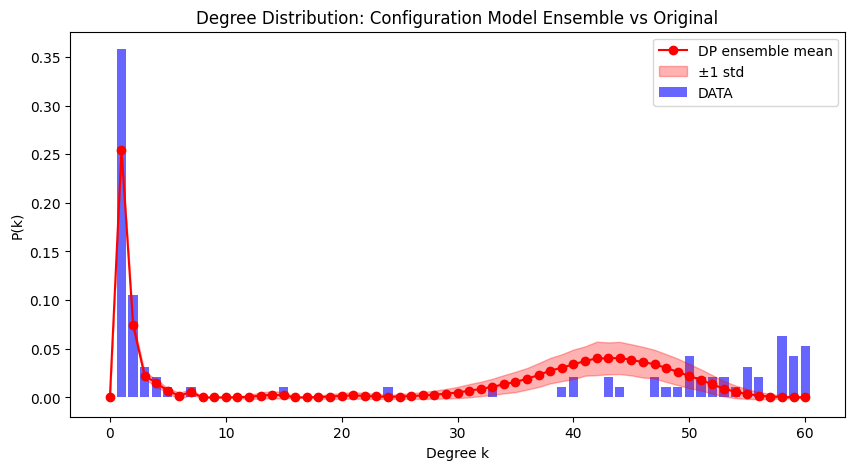

In [63]:
plt.figure(figsize=(10, 5))
# Data distribution 
hist_orig, bins_orig = np.histogram(deg_seq,
                                     bins=np.arange(0, max_deg_DP+2),
                                     density=True)
plt.bar(bins_orig[:-1], hist_orig, alpha=0.6, width=0.8,
        label='DATA', align='center', color='blue')
# DP ensenmble mean and standaard deviation
plt.plot(k_values_DP, mean_p_DP, 'o-', color='red', label="DP ensemble mean")
plt.fill_between(k_values_DP, mean_p_DP - std_p_DP, mean_p_DP + std_p_DP, alpha=0.3, color='red', label="±1 std")


plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution: Configuration Model Ensemble vs Original')
plt.legend()
plt.show()

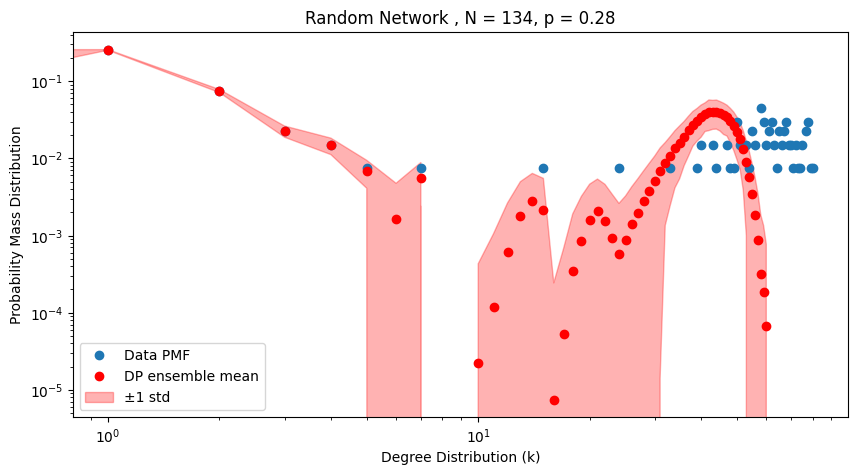

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(x0[:-1], y0, 'o', label = 'Data PMF')

plt.plot(k_values_DP, mean_p_DP, 'o',color='red', label="DP ensemble mean")
plt.fill_between(k_values_DP, mean_p_DP - std_p_DP, mean_p_DP + std_p_DP, alpha=0.3, color='red', label="±1 std")


#Applying log to both axis
plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))
#plt.xlim([0,40])
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

In [68]:
# Average knn for DP
all_ks = set()
for dic in knn_lists_DP:
    all_ks.update(dic.keys())
knn_DP = {}
for k in all_ks:
    vals = [dic.get(k) for dic in knn_lists_DP if k in dic]
    if vals:
        knn_DP[k] = np.mean(vals)

# clustering coefficient and average path length between Data, ER ensemble and the DP ensemble 

In [69]:
d = nx.average_shortest_path_length(G)

# Table for global quantities
data_table = {
    'Metric': ['Clustering coefficient', 'Average path length'],
    'Data': [C, d],
    'ER': [f'{mean_C_ER:.2f} ± {std_C_ER:.3f}', f'{mean_d_ER:.2f} ± {std_d_ER:.3f}'],
    'DP': [f'{mean_C_DP:.2f} ± {std_C_DP:.3f}', f'{mean_d_DP:.2f} ± {std_d_DP:.3f}']
}
df_table = pd.DataFrame(data_table)
df_table.set_index('Metric', inplace=True)
df_table

,Data,ER,DP
Metric,,,
Clustering coefficient,0.602338,0.28 ± 0.005,0.37 ± 0.014
Average path length,1.966783,1.72 ± 0.005,2.16 ± 0.012


# average nearest neighbor degree between Data, ER ensemble and the DP ensemble 

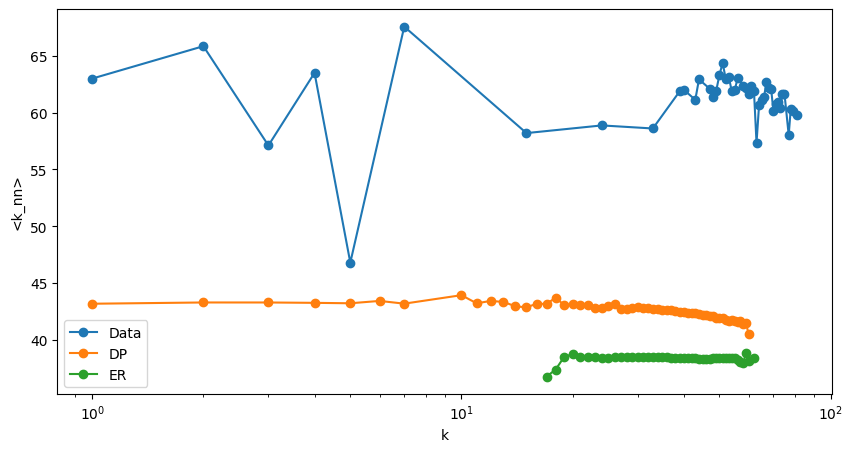

In [70]:
# Plot
fig = plt.figure(figsize=(10,5))
ks = sorted(knn_data)
vals = [knn_data[k] for k in ks]
plt.plot(ks, vals, 'o-', label='Data')
ks_DP = sorted(knn_DP)
vals_DP = [knn_DP[k] for k in ks_DP]
plt.plot(ks_DP, vals_DP, 'o-', label='DP')
ks_ER = sorted(knn_ER)
vals_ER = [knn_ER[k] for k in ks_ER]
plt.plot(ks_ER, vals_ER, 'o-', label='ER')
plt.xlabel('k')
plt.ylabel('<k_nn>')
plt.xscale('log')
plt.legend()
plt.show()

# clustering coefficient between Data, ER ensemble and the DP ensemble 

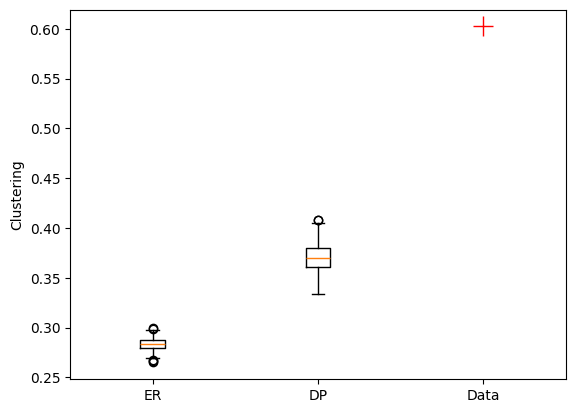

In [71]:

plt.boxplot([clustering_ER,clustering_DP], positions=[1,2])
plt.plot(3,C,'r',marker='+',markersize=15)
ax = plt.gca()
ax.set_xticks([1,2,3],labels=['ER','DP','Data'])
plt.ylabel('Clustering')
plt.xlim([0.5,3.5])
plt.show()

# average shortest path length between Data, ER ensemble and the DP ensemble 

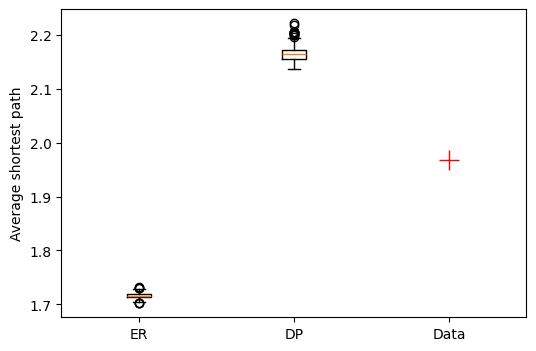

In [72]:
# Shortest path boxplot (using the ensemble data)
fig = plt.figure(figsize=(6,4))

plt.boxplot([short_path_ER,short_path_DP], positions=[1,2])
plt.plot(3,d,'r',marker='+',markersize=15)
ax = plt.gca()
ax.set_xticks([1,2,3],labels=['ER','DP','Data'])
plt.ylabel('Average shortest path')
plt.xlim([0.5,3.5])
plt.show()